NOTE: The dataset is not include in this repository. You can download the dataset from [here](https://www.kaggle.com/datasets/thedatasith/hymenoptera).

In [11]:
%cat .gitignore

.DS_Store
data


In [12]:
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from tempfile import TemporaryDirectory

In [13]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

In [14]:
transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
}

In [15]:
path = "data/hymenoptera_data"
datasources = { each: datasets.ImageFolder(os.path.join(path, each), transforms[each]) for each in ["train", "val"] }
dataloaders = { each: torch.utils.data.DataLoader(datasources[each], batch_size=4, shuffle=True, num_workers=4) for each in ["train", "val"] }

In [16]:
def imshow(input, title=None):
    input = input.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input = std * input + mean
    input = np.clip(input, 0, 1)
    plt.imshow(input)
    if title != None:
        plt.title(title)
    plt.pause(0.001)

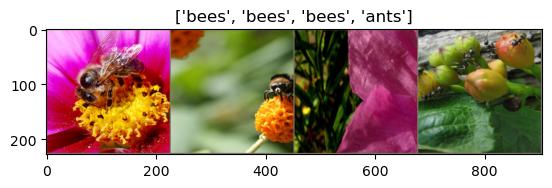

In [ ]:
if False:
    inputs, classes = next(iter(dataloaders["train"]))
    out = torchvision.utils.make_grid(inputs)
    imshow(out, title=[datasources["train"].classes[x] for x in classes])

In [23]:
BEST_MODEL_PARAMS_PATH = "best_model.pth"

class Trainer:
    def __init__(self, model, criterion, optimizer, scheduler=None):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
    
    def save(self, path=BEST_MODEL_PARAMS_PATH):
        torch.save(self.model.state_dict(), path)

    def train(self, dataloaders, model_params_path=BEST_MODEL_PARAMS_PATH, epochs=25):
        started_at = time.time()
        with TemporaryDirectory() as tempdir:
            model_params_path = os.path.join(tempdir, model_params_path)

            self.save()
            best_acc = 0.0

            for epoch in range(epochs):
                print(f"Epoch {epoch+1}/{epochs}")
                print("-" * 10)

                for phase in ["train", "val"]:
                    if phase == "train":
                        self.model.train()
                    else:
                        self.model.eval()
                    
                    running_loss = 0.0
                    running_corrects = 0

                    for inputs, labels in dataloaders[phase]:
                        inputs = inputs.to(device)
                        lebels = labels.to(device)

                        self.optimizer.zero_grad()

                        with torch.set_grad_enabled(phase == "train"):
                            outputs = self.model(inputs)
                            _, preds = torch.max(outputs, 1)
                            loss = self.criterion(outputs, labels)

                            if phase == "train":
                                loss.backward()
                                self.optimizer.step()
                        
                        running_loss += loss.item() * inputs.size(0)
                        running_corrects += torch.sum(preds == labels.data)
                    
                    if phase == "train":
                        if self.scheduler:
                            self.scheduler.step()
                    
                    epoch_loss = running_loss / len(dataloaders[phase].dataset)
                    epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

                    print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

                    if phase == "val" and epoch_acc > best_acc:
                        best_acc = epoch_acc
                        self.save(model_params_path)
                        print(f"Best model saved to {model_params_path}")

                print()
            time_elapsed = time.time() - started_at
            print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
            print(f"Best val Acc: {best_acc:.4f}")
        
            self.model.load_state_dict(torch.load(model_params_path))
            self.model = self.model.to(device)
        return self.model
    
    def visualize(self, num_images=6):
        was_training = self.model.training
        self.model.eval()
        images_so_far = 0
        fig = plt.figure()

        with torch.no_grad():
            for i, (inputs, labels) in enumerate(dataloaders["val"]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = self.model(inputs)
                _, preds = torch.max(outputs, 1)

                for j in range(inputs.size()[0]):
                    images_so_far += 1
                    ax = plt.subplot(num_images // 2, 2, images_so_far)
                    ax.axis("off")
                    ax.set_title(f"{datasources['val'].classes[preds[j]]} ({datasources['val'].classes[labels[j]]})")
                    imshow(inputs.cpu().data[j])
                    
                    if images_so_far == num_images:
                        self.model.train(mode=was_training)
                        return
            self.model.train(mode=was_training)


In [24]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features

model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss().to(device)

optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [25]:
trainer = Trainer(model_ft, criterion, optimizer_ft, exp_lr_scheduler)
model_ft = trainer.train(dataloaders, epochs=25)
trainer.visualize()

Epoch 1/25
----------


RuntimeError: Placeholder storage has not been allocated on MPS device!

In [28]:
class_names = datasources['train'].classes

def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)